> **Notebook Goal**\n> Train a KNN income classifier, measure global individual fairness (IF), then report within-group IF for marital-status, sex, and their intersection.


> **Imports**\n> Load pandas and scikit-learn components for preprocessing, KNN training, and evaluation metrics.


In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


> **Targets and Sensitive Attributes**\n> Define the prediction target and list sensitive attributes. Sensitive attributes are excluded from training features and kept for fairness analysis.


In [2]:
target = "income-class"
sensitive_cols = ["marital-status", "relationship", "race", "sex", "native-country"]

> **Load and Split Data**\n> Read the Adult dataset, separate train/test sets, and preserve sensitive columns for later subgroup analysis.


In [3]:
data = pd.read_csv("adult.data.csv", na_values="?", skipinitialspace=True)

feature_cols = [c for c in data.columns if c not in [target] + sensitive_cols]
X = data[feature_cols]
y = data[target]
X_sensitive = data[sensitive_cols]

X_train, X_test, y_train, y_test, _, X_sensitivefeatures_test = train_test_split(
    X, y, X_sensitive, test_size=0.20, random_state=42, stratify=y
)

> **Preprocessing Pipeline**\n> Create numeric and categorical preprocessing steps (impute + scale / one-hot) used by the KNN pipeline.


In [4]:
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

> **Train Baseline KNN**\n> Fit the selected KNN configuration and print standard classification metrics before fairness analysis.


In [5]:
classifier = KNeighborsClassifier(
    n_neighbors=17,
    weights="uniform",
    leaf_size=20,
    p=2,
)

classifierPipeline = Pipeline([
    ("preprocess", preprocess),
    ("knn", classifier),
])

classifierPipeline.fit(X_train, y_train)
y_predict = classifierPipeline.predict(X_test)  # <- use pipeline here

print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

[[4615  330]
 [ 860  708]]
              precision    recall  f1-score   support

       <=50K       0.84      0.93      0.89      4945
        >50K       0.68      0.45      0.54      1568

    accuracy                           0.82      6513
   macro avg       0.76      0.69      0.71      6513
weighted avg       0.80      0.82      0.80      6513



## Individual Fairness Analysis (Minimal)
Concise IF audit using local nearest-neighbor pairs, probability outputs, and a normalized distance metric in preprocessed non-sensitive feature space.


> **Global IF (Local Pair Audit)**\n> Compute local pairs, normalize distances, calculate violations `max(0, |p_i-p_j| - d_ij)`, and print the global IF summary.


In [6]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Probability output p(x) for the positive class
p = classifierPipeline.predict_proba(X_test)[:, list(classifierPipeline.classes_).index(">50K")]

# Similarity metric d(x, y): normalized distance in preprocessed non-sensitive feature space
X_test_preprocessed = classifierPipeline.named_steps["preprocess"].transform(X_test)

# Local pairs: fixed number of nearest neighbors (excluding self)
k_local = 15
nn = NearestNeighbors(n_neighbors=min(k_local + 1, len(X_test)), metric="euclidean")
nn.fit(X_test_preprocessed)
distances, indices = nn.kneighbors(X_test_preprocessed)

rows = np.repeat(np.arange(len(X_test)), distances.shape[1] - 1)
cols = indices[:, 1:].reshape(-1)
raw_d = distances[:, 1:].reshape(-1)

# Normalize distances into [0, 1]
scale = raw_d.max()
if scale == 0:
    scale = 1.0
d = np.clip(raw_d / scale, 0.0, 1.0)

# Fairness violations: max(0, |p_i - p_j| - d_ij)
delta_p = np.abs(p[rows] - p[cols])
violations = np.maximum(0.0, delta_p - d)

print("Individual fairness (local) summary")
print("- evaluated pairs:", len(violations))
print("- max_violation:", round(float(violations.max()), 6))
print("- avg_violation:", round(float(violations.mean()), 6))
print("- violation_rate:", round(float((violations > 0).mean()), 6))


Individual fairness (local) summary
- evaluated pairs: 97695
- max_violation: 0.773675
- avg_violation: 0.022848
- violation_rate: 0.260648


> **Subgroup and Intersection IF**\n> Reuse the pair-level fairness outputs to report within-group IF for marital-status, sex, and the marital-status x sex intersection.


In [7]:
# Within-group IF for selected analysis attributes and their intersection
required = ["rows", "cols", "violations", "X_sensitivefeatures_test"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError("Run the local fairness cell first. Missing: " + ", ".join(missing))

sensitive_test = X_sensitivefeatures_test.reset_index(drop=True).copy()
analysis_attrs = ["marital-status", "sex"]


def within_group_if_table_from_labels(labels, attribute_name):
    labels = labels.fillna("<missing>").astype(str)
    labels_arr = labels.to_numpy()
    group_i = labels_arr[rows]
    group_j = labels_arr[cols]
    within_mask = group_i == group_j
    sample_counts = labels.value_counts().to_dict()

    records = []
    for subgroup in sorted(sample_counts):
        mask = within_mask & (group_i == subgroup)
        n_pairs = int(mask.sum())
        if n_pairs == 0:
            records.append({
                "attribute": attribute_name,
                "subgroup": subgroup,
                "n_samples": int(sample_counts[subgroup]),
                "n_pairs": 0,
                "max_violation": np.nan,
                "avg_violation": np.nan,
                "violation_rate": np.nan,
            })
            continue

        v = violations[mask]
        records.append({
            "attribute": attribute_name,
            "subgroup": subgroup,
            "n_samples": int(sample_counts[subgroup]),
            "n_pairs": n_pairs,
            "max_violation": float(v.max()),
            "avg_violation": float(v.mean()),
            "violation_rate": float((v > 0).mean()),
        })

    table = pd.DataFrame(records)
    return table.sort_values(["violation_rate", "n_pairs"], ascending=[False, False], na_position="last")

for attribute in analysis_attrs:
    print(f"\nWithin-group IF by {attribute}")
    print(within_group_if_table_from_labels(sensitive_test[attribute], attribute).to_string(index=False))

intersection_name = "marital-status x sex"
intersection_labels = (
    sensitive_test["marital-status"].fillna("<missing>").astype(str)
    + " | "
    + sensitive_test["sex"].fillna("<missing>").astype(str)
)
print("\nWithin-group IF by (marital-status, sex) intersection")
print(
    within_group_if_table_from_labels(
        intersection_labels,
        intersection_name,
    ).to_string(index=False)
)



Within-group IF by marital-status
     attribute              subgroup  n_samples  n_pairs  max_violation  avg_violation  violation_rate
marital-status              Divorced        883     2640       0.396209       0.024547        0.318561
marital-status    Married-civ-spouse       2977    25074       0.773675       0.028579        0.301508
marital-status         Never-married       2181    18553       0.601545       0.012216        0.152482
marital-status             Separated        199      144       0.403079       0.011038        0.145833
marital-status Married-spouse-absent         86       14       0.038749       0.005536        0.142857
marital-status               Widowed        182      358       0.273141       0.004430        0.069832
marital-status     Married-AF-spouse          5        0            NaN            NaN             NaN

Within-group IF by sex
attribute subgroup  n_samples  n_pairs  max_violation  avg_violation  violation_rate
      sex     Male       4355   

## Cause of Unfairness (Data, Minimal)
Start with data-only evidence: representation skew, label-rate skew, and local-pair coverage. This adds diagnostics only and does not retrain the model.


> **Data Skew Diagnostics (Minimal Next Step)**
> Prints subgroup/intersection counts, `>50K` rates, and local IF pair coverage (`n_pairs`) for `marital-status`, `sex`, and `marital-status x sex`.


In [8]:
# Minimal data-skew diagnostics (no retraining)
required = [
    "data", "target", "y_test", "X_sensitivefeatures_test",
    "rows", "cols", "violations",
    "within_group_if_table_from_labels", "analysis_attrs",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError("Run the earlier cells first. Missing: " + ", ".join(missing))

positive_label = ">50K"
intersection_name = globals().get("intersection_name", "marital-status x sex")

# Full dataset: representation + label skew by subgroup / intersection
full_diag = data[analysis_attrs + [target]].copy()
full_diag[intersection_name] = (
    full_diag[analysis_attrs[0]].fillna("<missing>").astype(str)
    + " | "
    + full_diag[analysis_attrs[1]].fillna("<missing>").astype(str)
)
full_diag["__positive__"] = (full_diag[target] == positive_label).astype(int)

# Test split version (useful for comparing with IF outputs computed on test data)
test_diag = X_sensitivefeatures_test[analysis_attrs].reset_index(drop=True).copy()
test_diag[target] = y_test.reset_index(drop=True)
test_diag[intersection_name] = (
    test_diag[analysis_attrs[0]].fillna("<missing>").astype(str)
    + " | "
    + test_diag[analysis_attrs[1]].fillna("<missing>").astype(str)
)
test_diag["__positive__"] = (test_diag[target] == positive_label).astype(int)

for label, frame in [("full dataset", full_diag), ("test split", test_diag)]:
    print(f"\nData skew diagnostics ({label})")
    for attr in analysis_attrs + [intersection_name]:
        summary = (
            frame.groupby(attr)
            .agg(
                n_samples=(attr, "size"),
                positive_rate=("__positive__", "mean"),
            )
            .sort_values(["n_samples"], ascending=False)
        )
        summary["positive_rate"] = summary["positive_rate"].round(4)
        print(f"\nCounts and positive rate by {attr}")
        print(summary.to_string())

# Pair coverage in the already-computed local IF graph (within-group only)
print("\nLocal-pair coverage in the current IF audit (test split)")
for attr in analysis_attrs:
    tbl = within_group_if_table_from_labels(sensitive_test[attr], attr)
    print(f"\nPair coverage summary for {attr}")
    print(tbl[["subgroup", "n_samples", "n_pairs", "violation_rate"]].to_string(index=False))

intersection_labels = (
    sensitive_test[analysis_attrs[0]].fillna("<missing>").astype(str)
    + " | "
    + sensitive_test[analysis_attrs[1]].fillna("<missing>").astype(str)
)
intersection_tbl = within_group_if_table_from_labels(intersection_labels, intersection_name)
print(f"\nPair coverage summary for {intersection_name}")
print(intersection_tbl[["subgroup", "n_samples", "n_pairs", "violation_rate"]].to_string(index=False))



Data skew diagnostics (full dataset)

Counts and positive rate by marital-status
                       n_samples  positive_rate
marital-status                                 
Married-civ-spouse         14976         0.4468
Never-married              10683         0.0460
Divorced                    4443         0.1042
Separated                   1025         0.0644
Widowed                      993         0.0856
Married-spouse-absent        418         0.0813
Married-AF-spouse             23         0.4348

Counts and positive rate by sex
        n_samples  positive_rate
sex                             
Male        21790         0.3057
Female      10771         0.1095

Counts and positive rate by marital-status x sex
                                n_samples  positive_rate
marital-status x sex                                    
Married-civ-spouse | Male           13319         0.4458
Never-married | Male                 5916         0.0549
Never-married | Female               4767  

## Cause of Unfairness (Data Intervention, Minimal)
A single controlled data intervention: rebalance the training set by `sex` using undersampling, keep the test set and method fixed, and compare fairness/performance to baseline.


> **Sex-Balanced Undersampling (3 Seeds)**
> Repeats a train-only sex-balanced undersampling experiment with 3 seeds, while reporting both `sex` IF gap and a `marital-status` IF spread summary so both selected sensitive attributes remain in scope.


In [9]:
# Minimal data intervention: sex-balanced undersampling (3 seeds)
import time
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.neighbors import NearestNeighbors

required = [
    "classifierPipeline", "X_train", "X_test", "y_train", "y_test",
    "data", "target", "analysis_attrs", "X_sensitivefeatures_test",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError("Run the earlier cells first. Missing: " + ", ".join(missing))

if9_positive_label = ">50K"
if9_k_local = 15
if9_seeds = [42, 43, 44]
if9_intersection_name = "marital-status x sex"
if9_min_pairs_for_marital_summary = 100


def if9_within_group_if_table_from_labels(labels, rows_, cols_, violations_, attribute_name):
    labels = labels.fillna("<missing>").astype(str)
    labels_arr = labels.to_numpy()
    group_i = labels_arr[rows_]
    group_j = labels_arr[cols_]
    within_mask = group_i == group_j
    sample_counts = labels.value_counts().to_dict()

    records = []
    for subgroup in sorted(sample_counts):
        mask = within_mask & (group_i == subgroup)
        n_pairs = int(mask.sum())
        if n_pairs == 0:
            records.append({
                "attribute": attribute_name,
                "subgroup": subgroup,
                "n_samples": int(sample_counts[subgroup]),
                "n_pairs": 0,
                "max_violation": np.nan,
                "avg_violation": np.nan,
                "violation_rate": np.nan,
            })
            continue

        v = violations_[mask]
        records.append({
            "attribute": attribute_name,
            "subgroup": subgroup,
            "n_samples": int(sample_counts[subgroup]),
            "n_pairs": n_pairs,
            "max_violation": float(v.max()),
            "avg_violation": float(v.mean()),
            "violation_rate": float((v > 0).mean()),
        })

    table = pd.DataFrame(records)
    return table.sort_values(["violation_rate", "n_pairs"], ascending=[False, False], na_position="last")


def if9_violation_rate_spread(table, min_pairs=100):
    valid = table[(table["n_pairs"] >= int(min_pairs)) & table["violation_rate"].notna()].copy()
    if valid.empty:
        return np.nan
    return float(valid["violation_rate"].max() - valid["violation_rate"].min())


def if9_evaluate_model(fitted_model):
    # Performance metrics (same test set)
    y_pred_local = fitted_model.predict(X_test)
    performance = {
        "accuracy": float(accuracy_score(y_test, y_pred_local)),
        "macro_f1": float(f1_score(y_test, y_pred_local, average="macro")),
        "positive_recall": float(recall_score(y_test, y_pred_local, pos_label=if9_positive_label)),
    }

    # Global IF (same local-pair protocol as earlier cell)
    proba = fitted_model.predict_proba(X_test)
    pos_idx = list(fitted_model.classes_).index(if9_positive_label)
    p_local = proba[:, pos_idx]

    X_test_preprocessed_local = fitted_model.named_steps["preprocess"].transform(X_test)
    nn_local = NearestNeighbors(n_neighbors=min(if9_k_local + 1, len(X_test)), metric="euclidean")
    nn_local.fit(X_test_preprocessed_local)
    distances_local, indices_local = nn_local.kneighbors(X_test_preprocessed_local)

    rows_local = np.repeat(np.arange(len(X_test)), distances_local.shape[1] - 1)
    cols_local = indices_local[:, 1:].reshape(-1)
    raw_d_local = distances_local[:, 1:].reshape(-1)

    scale_local = float(raw_d_local.max()) if raw_d_local.size else 1.0
    if scale_local == 0:
        scale_local = 1.0
    d_local = np.clip(raw_d_local / scale_local, 0.0, 1.0)

    delta_p_local = np.abs(p_local[rows_local] - p_local[cols_local])
    violations_local = np.maximum(0.0, delta_p_local - d_local)

    sensitive_test_local = X_sensitivefeatures_test[analysis_attrs].reset_index(drop=True).copy()
    sex_tbl = if9_within_group_if_table_from_labels(
        sensitive_test_local["sex"], rows_local, cols_local, violations_local, "sex"
    )
    marital_tbl = if9_within_group_if_table_from_labels(
        sensitive_test_local["marital-status"], rows_local, cols_local, violations_local, "marital-status"
    )

    intersection_labels_local = (
        sensitive_test_local["marital-status"].fillna("<missing>").astype(str)
        + " | "
        + sensitive_test_local["sex"].fillna("<missing>").astype(str)
    )
    intersection_tbl = if9_within_group_if_table_from_labels(
        intersection_labels_local, rows_local, cols_local, violations_local, if9_intersection_name
    )

    return {
        "performance": performance,
        "global_if": {
            "evaluated_pairs": int(len(violations_local)),
            "max_violation": float(violations_local.max()) if violations_local.size else 0.0,
            "avg_violation": float(violations_local.mean()) if violations_local.size else 0.0,
            "violation_rate": float((violations_local > 0).mean()) if violations_local.size else 0.0,
        },
        "sex_table": sex_tbl,
        "marital_table": marital_tbl,
        "intersection_table": intersection_tbl,
    }


def if9_get_violation_rate(table, subgroup_name):
    row = table[table["subgroup"] == subgroup_name]
    if row.empty:
        return np.nan
    return float(row.iloc[0]["violation_rate"])


def if9_sex_balanced_train_index(seed):
    train_sex = data.loc[X_train.index, "sex"].astype(str)
    counts = train_sex.value_counts()
    if len(counts) != 2:
        raise ValueError(f"Expected 2 sex groups, got: {counts.to_dict()}")

    minority_n = int(counts.min())
    rng = np.random.default_rng(seed)
    selected = []
    for group_name in sorted(counts.index.tolist()):
        group_index = train_sex[train_sex == group_name].index.to_numpy()
        if len(group_index) > minority_n:
            chosen = rng.choice(group_index, size=minority_n, replace=False)
        else:
            chosen = group_index
        selected.append(chosen)

    selected_index = pd.Index(np.concatenate(selected)).sort_values()
    return selected_index, counts.to_dict(), minority_n


# Baseline (current fitted model) for comparison
if9_baseline_eval = if9_evaluate_model(classifierPipeline)
if9_baseline_male = if9_get_violation_rate(if9_baseline_eval["sex_table"], "Male")
if9_baseline_female = if9_get_violation_rate(if9_baseline_eval["sex_table"], "Female")
if9_baseline_marital_spread = if9_violation_rate_spread(
    if9_baseline_eval["marital_table"], min_pairs=if9_min_pairs_for_marital_summary
)

if9_rows = [{
    "experiment": "baseline_current_train",
    "seed": np.nan,
    "train_rows": int(len(X_train)),
    "accuracy": if9_baseline_eval["performance"]["accuracy"],
    "macro_f1": if9_baseline_eval["performance"]["macro_f1"],
    "positive_recall": if9_baseline_eval["performance"]["positive_recall"],
    "global_if_violation_rate": if9_baseline_eval["global_if"]["violation_rate"],
    "global_if_avg_violation": if9_baseline_eval["global_if"]["avg_violation"],
    "sex_if_male": if9_baseline_male,
    "sex_if_female": if9_baseline_female,
    "sex_if_gap_male_minus_female": if9_baseline_male - if9_baseline_female,
    "marital_if_spread_min100": if9_baseline_marital_spread,
    "notes": "Original training data",
}]

print("Sex-balanced undersampling experiment (3 seeds)")
print("- Baseline train rows:", len(X_train))
print("- Also reporting marital-status IF spread (max-min subgroup violation_rate, n_pairs >= {})".format(if9_min_pairs_for_marital_summary))

for seed in if9_seeds:
    train_index_bal, sex_counts_train, target_n = if9_sex_balanced_train_index(seed)
    print(f"\nSeed {seed}: sex counts in original train = {sex_counts_train}; selected per sex = {target_n}; selected rows = {len(train_index_bal)}")

    pipe_bal = clone(classifierPipeline)
    start = time.time()
    pipe_bal.fit(X_train.loc[train_index_bal], y_train.loc[train_index_bal])
    elapsed = time.time() - start

    eval_bal = if9_evaluate_model(pipe_bal)
    male_rate = if9_get_violation_rate(eval_bal["sex_table"], "Male")
    female_rate = if9_get_violation_rate(eval_bal["sex_table"], "Female")
    marital_spread = if9_violation_rate_spread(eval_bal["marital_table"], min_pairs=if9_min_pairs_for_marital_summary)

    if9_rows.append({
        "experiment": "sex_balanced_undersample",
        "seed": int(seed),
        "train_rows": int(len(train_index_bal)),
        "accuracy": eval_bal["performance"]["accuracy"],
        "macro_f1": eval_bal["performance"]["macro_f1"],
        "positive_recall": eval_bal["performance"]["positive_recall"],
        "global_if_violation_rate": eval_bal["global_if"]["violation_rate"],
        "global_if_avg_violation": eval_bal["global_if"]["avg_violation"],
        "sex_if_male": male_rate,
        "sex_if_female": female_rate,
        "sex_if_gap_male_minus_female": male_rate - female_rate,
        "marital_if_spread_min100": marital_spread,
        "fit_time_sec": float(elapsed),
        "notes": "Sex-balanced undersampling (train only)",
    })

if9_results = pd.DataFrame(if9_rows)
baseline_row = if9_results.loc[if9_results["experiment"] == "baseline_current_train"].iloc[0]
for metric in [
    "accuracy", "macro_f1", "positive_recall",
    "global_if_violation_rate", "global_if_avg_violation",
    "sex_if_gap_male_minus_female", "marital_if_spread_min100",
]:
    if9_results[f"delta_{metric}"] = if9_results[metric] - float(baseline_row[metric])

print("\nBaseline vs 3 sex-balanced runs")
print(
    if9_results[
        [
            "experiment", "seed", "train_rows",
            "accuracy", "macro_f1", "positive_recall",
            "global_if_violation_rate", "global_if_avg_violation",
            "sex_if_male", "sex_if_female", "sex_if_gap_male_minus_female",
            "marital_if_spread_min100",
            "delta_accuracy", "delta_macro_f1", "delta_positive_recall",
            "delta_global_if_violation_rate", "delta_global_if_avg_violation",
            "delta_sex_if_gap_male_minus_female", "delta_marital_if_spread_min100",
        ]
    ].round(6).to_string(index=False)
)

balanced_only = if9_results[if9_results["experiment"] == "sex_balanced_undersample"].copy()
if not balanced_only.empty:
    summary = balanced_only[
        [
            "accuracy", "macro_f1", "positive_recall",
            "global_if_violation_rate", "global_if_avg_violation",
            "sex_if_gap_male_minus_female", "marital_if_spread_min100",
            "delta_accuracy", "delta_macro_f1", "delta_positive_recall",
            "delta_global_if_violation_rate", "delta_global_if_avg_violation",
            "delta_sex_if_gap_male_minus_female", "delta_marital_if_spread_min100",
        ]
    ].agg(["mean", "std"]).round(6)
    print("\nSex-balanced runs (3 seeds) summary: mean / std")
    print(summary.to_string())


Sex-balanced undersampling experiment (3 seeds)
- Baseline train rows: 26048
- Also reporting marital-status IF spread (max-min subgroup violation_rate, n_pairs >= 100)

Seed 42: sex counts in original train = {'Male': 17435, 'Female': 8613}; selected per sex = 8613; selected rows = 17226

Seed 43: sex counts in original train = {'Male': 17435, 'Female': 8613}; selected per sex = 8613; selected rows = 17226

Seed 44: sex counts in original train = {'Male': 17435, 'Female': 8613}; selected per sex = 8613; selected rows = 17226

Baseline vs 3 sex-balanced runs
              experiment  seed  train_rows  accuracy  macro_f1  positive_recall  global_if_violation_rate  global_if_avg_violation  sex_if_male  sex_if_female  sex_if_gap_male_minus_female  marital_if_spread_min100  delta_accuracy  delta_macro_f1  delta_positive_recall  delta_global_if_violation_rate  delta_global_if_avg_violation  delta_sex_if_gap_male_minus_female  delta_marital_if_spread_min100
  baseline_current_train   NaN    

## Cause of Unfairness (Data, Proxy Signal)
Minimal proxy-signal check: test whether protected-attribute information (`sex`) is still recoverable from the non-sensitive features used by the KNN classifier.


> **Proxy Signal Check (Minimal)**
> Train simple probes to predict both `sex` and `marital-status` from the same KNN input features, each compared to a majority-class baseline. Strong probe performance suggests proxy information remains in the data.


In [10]:
# Minimal proxy signal check: can KNN input features predict sex and marital-status?
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

required = ["data", "X_train", "X_test", "X_sensitivefeatures_test", "preprocess"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError("Run the earlier cells first. Missing: " + ", ".join(missing))

if10_proxy_attrs = ["sex", "marital-status"]


def if10_run_proxy_probe(protected_attr, random_state=42):
    y_train_proxy = data.loc[X_train.index, protected_attr].astype(str)
    y_test_proxy = X_sensitivefeatures_test[protected_attr].astype(str)

    majority_class = y_train_proxy.value_counts().idxmax()
    y_pred_majority = np.repeat(majority_class, len(y_test_proxy))

    probe = Pipeline([
        ("preprocess", clone(preprocess)),
        ("logreg", LogisticRegression(max_iter=1000, solver="liblinear", random_state=random_state)),
    ])
    probe.fit(X_train, y_train_proxy)
    y_pred_probe = probe.predict(X_test)

    probe_classes = list(probe.named_steps["logreg"].classes_)
    is_binary = len(probe_classes) == 2
    roc_auc = np.nan
    auc_note = "not reported (multiclass probe)"
    if is_binary:
        auc_positive_class = probe_classes[-1]
        if protected_attr == "sex" and "Male" in probe_classes:
            auc_positive_class = "Male"
        auc_pos_idx = probe_classes.index(auc_positive_class)
        y_prob_pos = probe.predict_proba(X_test)[:, auc_pos_idx]
        y_true_pos = (y_test_proxy.to_numpy() == auc_positive_class).astype(int)
        roc_auc = float(roc_auc_score(y_true_pos, y_prob_pos))
        auc_note = f"AUC positive class: {auc_positive_class}"

    results = pd.DataFrame([
        {
            "protected_attribute": protected_attr,
            "model": "majority_baseline",
            "accuracy": float(accuracy_score(y_test_proxy, y_pred_majority)),
            "macro_f1": float(f1_score(y_test_proxy, y_pred_majority, average="macro")),
            "roc_auc": np.nan,
            "notes": f"Always predict training majority class: {majority_class}",
        },
        {
            "protected_attribute": protected_attr,
            "model": "logistic_probe",
            "accuracy": float(accuracy_score(y_test_proxy, y_pred_probe)),
            "macro_f1": float(f1_score(y_test_proxy, y_pred_probe, average="macro")),
            "roc_auc": roc_auc,
            "notes": f"Predict {protected_attr} from KNN input features only ({auc_note})",
        },
    ])

    baseline_acc = float(results.loc[results["model"] == "majority_baseline", "accuracy"].iloc[0])
    baseline_f1 = float(results.loc[results["model"] == "majority_baseline", "macro_f1"].iloc[0])
    results["delta_vs_majority_accuracy"] = results["accuracy"] - baseline_acc
    results["delta_vs_majority_macro_f1"] = results["macro_f1"] - baseline_f1

    train_dist = y_train_proxy.value_counts().rename("train_count")
    train_dist = pd.concat([train_dist, (train_dist / train_dist.sum()).rename("train_rate")], axis=1)
    test_dist = y_test_proxy.value_counts().rename("test_count")
    test_dist = pd.concat([test_dist, (test_dist / test_dist.sum()).rename("test_rate")], axis=1)

    return {
        "results": results,
        "train_dist": train_dist,
        "test_dist": test_dist,
    }


print("Proxy signal check (protected attributes = sex and marital-status)")
print("- Question: How predictable are the selected protected attributes from the non-sensitive features used by the KNN model?")
print("- Interpretation: If probes substantially beat majority baselines, proxy signal is present.")

all_proxy_results = []
for protected_attr in if10_proxy_attrs:
    probe_out = if10_run_proxy_probe(protected_attr)
    all_proxy_results.append(probe_out["results"])

    print(f"\nTrain distribution ({protected_attr})")
    print(probe_out["train_dist"].round(4).to_string())

    print(f"\nTest distribution ({protected_attr})")
    print(probe_out["test_dist"].round(4).to_string())

    print(f"\nProxy probe results ({protected_attr} from KNN input features)")
    print(probe_out["results"].round(6).to_string(index=False))

if10_proxy_results_all = pd.concat(all_proxy_results, ignore_index=True)
print("\nCombined proxy probe results (sex + marital-status)")
print(if10_proxy_results_all.round(6).to_string(index=False))


Proxy signal check (protected attributes = sex and marital-status)
- Question: How predictable are the selected protected attributes from the non-sensitive features used by the KNN model?
- Interpretation: If probes substantially beat majority baselines, proxy signal is present.

Train distribution (sex)
        train_count  train_rate
sex                            
Male          17435      0.6693
Female         8613      0.3307

Test distribution (sex)
        test_count  test_rate
sex                          
Male          4355     0.6687
Female        2158     0.3313

Proxy probe results (sex from KNN input features)
protected_attribute             model  accuracy  macro_f1  roc_auc                                                               notes  delta_vs_majority_accuracy  delta_vs_majority_macro_f1
                sex majority_baseline  0.668663  0.400718      NaN                        Always predict training majority class: Male                    0.000000                 

c:\Users\brand\anaconda3\envs\sklearn\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Train distribution (marital-status)
                       train_count  train_rate
marital-status                                
Married-civ-spouse           11999      0.4606
Never-married                 8502      0.3264
Divorced                      3560      0.1367
Separated                      826      0.0317
Widowed                        811      0.0311
Married-spouse-absent          332      0.0127
Married-AF-spouse               18      0.0007

Test distribution (marital-status)
                       test_count  test_rate
marital-status                              
Married-civ-spouse           2977     0.4571
Never-married                2181     0.3349
Divorced                      883     0.1356
Separated                     199     0.0306
Widowed                       182     0.0279
Married-spouse-absent          86     0.0132
Married-AF-spouse               5     0.0008

Proxy probe results (marital-status from KNN input features)
protected_attribute             model

## Cause of Unfairness (Method, Minimal)
Minimal method-side test: keep data fixed and vary only the KNN neighborhood size `k` to measure how much the method assumptions change fairness and performance.


> **Method Sensitivity (Vary `k` Only)**
> Runs KNN with `k = 5, 17, 35` (keeping weights and distance norm fixed) and compares performance, global IF, the `sex` IF gap, and a `marital-status` IF spread summary.


In [11]:
# Minimal method investigation: vary only k (data fixed)
import time
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

required = [
    "classifierPipeline", "X_train", "X_test", "y_train", "y_test",
    "X_sensitivefeatures_test", "analysis_attrs",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError("Run the earlier cells first. Missing: " + ", ".join(missing))

if11_k_values = [5, 17, 35]
if11_fairness_k_local = 15
if11_positive_label = ">50K"
if11_min_pairs_for_marital_summary = 100

# Encode labels for method runs to avoid KNN predict_proba issues with string labels in some sklearn versions.
if11_le = LabelEncoder()
if11_y_train_enc = pd.Series(if11_le.fit_transform(y_train.astype(str)), index=y_train.index)
if11_y_test_enc = pd.Series(if11_le.transform(y_test.astype(str)), index=y_test.index)
if11_positive_label_enc = int(if11_le.transform([if11_positive_label])[0])


def if11_within_group_if_table(labels, rows_, cols_, violations_, attribute_name):
    labels = labels.fillna("<missing>").astype(str)
    labels_arr = labels.to_numpy()
    group_i = labels_arr[rows_]
    group_j = labels_arr[cols_]
    within_mask = group_i == group_j
    sample_counts = labels.value_counts().to_dict()

    records = []
    for subgroup in sorted(sample_counts):
        mask = within_mask & (group_i == subgroup)
        n_pairs = int(mask.sum())
        if n_pairs == 0:
            records.append({
                "attribute": attribute_name,
                "subgroup": subgroup,
                "n_samples": int(sample_counts[subgroup]),
                "n_pairs": 0,
                "max_violation": np.nan,
                "avg_violation": np.nan,
                "violation_rate": np.nan,
            })
            continue
        v = violations_[mask]
        records.append({
            "attribute": attribute_name,
            "subgroup": subgroup,
            "n_samples": int(sample_counts[subgroup]),
            "n_pairs": n_pairs,
            "max_violation": float(v.max()),
            "avg_violation": float(v.mean()),
            "violation_rate": float((v > 0).mean()),
        })
    return pd.DataFrame(records).sort_values(["violation_rate", "n_pairs"], ascending=[False, False], na_position="last")


def if11_violation_rate_spread(table, min_pairs=100):
    valid = table[(table["n_pairs"] >= int(min_pairs)) & table["violation_rate"].notna()].copy()
    if valid.empty:
        return np.nan
    return float(valid["violation_rate"].max() - valid["violation_rate"].min())


def if11_eval_method_model(fitted_model):
    # Performance on encoded labels (equivalent semantics to original string labels)
    y_pred_enc = fitted_model.predict(X_test)
    perf = {
        "accuracy": float(accuracy_score(if11_y_test_enc, y_pred_enc)),
        "macro_f1": float(f1_score(if11_y_test_enc, y_pred_enc, average="macro")),
        "positive_recall": float(recall_score(if11_y_test_enc, y_pred_enc, pos_label=if11_positive_label_enc)),
    }

    # Global IF with fixed local-pair protocol
    proba = fitted_model.predict_proba(X_test)
    pos_idx = list(fitted_model.classes_).index(if11_positive_label_enc)
    p_pos = proba[:, pos_idx]

    X_eval_preprocessed = fitted_model.named_steps["preprocess"].transform(X_test)
    nn_local = NearestNeighbors(n_neighbors=min(if11_fairness_k_local + 1, len(X_test)), metric="euclidean")
    nn_local.fit(X_eval_preprocessed)
    distances_local, indices_local = nn_local.kneighbors(X_eval_preprocessed)

    rows_local = np.repeat(np.arange(len(X_test)), distances_local.shape[1] - 1)
    cols_local = indices_local[:, 1:].reshape(-1)
    raw_d_local = distances_local[:, 1:].reshape(-1)
    scale_local = float(raw_d_local.max()) if raw_d_local.size else 1.0
    if scale_local == 0:
        scale_local = 1.0
    d_local = np.clip(raw_d_local / scale_local, 0.0, 1.0)
    delta_p_local = np.abs(p_pos[rows_local] - p_pos[cols_local])
    violations_local = np.maximum(0.0, delta_p_local - d_local)

    sensitive_local = X_sensitivefeatures_test[analysis_attrs].reset_index(drop=True).copy()
    sex_tbl = if11_within_group_if_table(sensitive_local["sex"], rows_local, cols_local, violations_local, "sex")
    marital_tbl = if11_within_group_if_table(sensitive_local["marital-status"], rows_local, cols_local, violations_local, "marital-status")

    male_row = sex_tbl[sex_tbl["subgroup"] == "Male"]
    female_row = sex_tbl[sex_tbl["subgroup"] == "Female"]
    male_rate = float(male_row.iloc[0]["violation_rate"]) if not male_row.empty else np.nan
    female_rate = float(female_row.iloc[0]["violation_rate"]) if not female_row.empty else np.nan
    marital_spread = if11_violation_rate_spread(marital_tbl, min_pairs=if11_min_pairs_for_marital_summary)

    return {
        "performance": perf,
        "global_if": {
            "evaluated_pairs": int(len(violations_local)),
            "max_violation": float(violations_local.max()) if violations_local.size else 0.0,
            "avg_violation": float(violations_local.mean()) if violations_local.size else 0.0,
            "violation_rate": float((violations_local > 0).mean()) if violations_local.size else 0.0,
        },
        "sex_if_male": male_rate,
        "sex_if_female": female_rate,
        "sex_if_gap_male_minus_female": male_rate - female_rate if pd.notna(male_rate) and pd.notna(female_rate) else np.nan,
        "marital_if_spread_min100": marital_spread,
    }


print("Minimal method investigation: vary only k (data fixed)")
print("- Fixed data split, preprocessing, weights='uniform', p=2, leaf_size=20")
print("- Fixed fairness protocol: local IF with k_local =", if11_fairness_k_local)
print("- Also reporting marital-status IF spread (max-min subgroup violation_rate, n_pairs >= {})".format(if11_min_pairs_for_marital_summary))
print("- k values:", if11_k_values)

if11_rows = []
for k_value in if11_k_values:
    pipe_k = clone(classifierPipeline)
    pipe_k.set_params(knn__n_neighbors=k_value, knn__weights="uniform", knn__p=2)

    start = time.time()
    pipe_k.fit(X_train, if11_y_train_enc)
    fit_elapsed = time.time() - start

    eval_k = if11_eval_method_model(pipe_k)
    row = {
        "k": int(k_value),
        "train_rows": int(len(X_train)),
        "fit_time_sec": float(fit_elapsed),
        "accuracy": eval_k["performance"]["accuracy"],
        "macro_f1": eval_k["performance"]["macro_f1"],
        "positive_recall": eval_k["performance"]["positive_recall"],
        "global_if_violation_rate": eval_k["global_if"]["violation_rate"],
        "global_if_avg_violation": eval_k["global_if"]["avg_violation"],
        "sex_if_male": eval_k["sex_if_male"],
        "sex_if_female": eval_k["sex_if_female"],
        "sex_if_gap_male_minus_female": eval_k["sex_if_gap_male_minus_female"],
        "marital_if_spread_min100": eval_k["marital_if_spread_min100"],
    }
    if11_rows.append(row)
    print(
        f"k={k_value}: acc={row['accuracy']:.4f}, macro_f1={row['macro_f1']:.4f}, "
        f"IF_violation_rate={row['global_if_violation_rate']:.4f}, sex_gap={row['sex_if_gap_male_minus_female']:.4f}, "
        f"marital_spread={row['marital_if_spread_min100']:.4f}"
    )

if11_results = pd.DataFrame(if11_rows).sort_values("k").reset_index(drop=True)
base_row = if11_results[if11_results["k"] == 17]
if base_row.empty:
    base_row = if11_results.iloc[[0]]
base_row = base_row.iloc[0]

for metric in [
    "accuracy", "macro_f1", "positive_recall",
    "global_if_violation_rate", "global_if_avg_violation",
    "sex_if_gap_male_minus_female", "marital_if_spread_min100",
]:
    if11_results[f"delta_vs_k{int(base_row['k'])}_{metric}"] = if11_results[metric] - float(base_row[metric])

print("\nMethod sensitivity summary (vary k only; baseline for deltas = k={})".format(int(base_row["k"])))
print(
    if11_results[
        [
            "k", "train_rows", "accuracy", "macro_f1", "positive_recall",
            "global_if_violation_rate", "global_if_avg_violation",
            "sex_if_male", "sex_if_female", "sex_if_gap_male_minus_female",
            "marital_if_spread_min100",
            f"delta_vs_k{int(base_row['k'])}_accuracy",
            f"delta_vs_k{int(base_row['k'])}_macro_f1",
            f"delta_vs_k{int(base_row['k'])}_positive_recall",
            f"delta_vs_k{int(base_row['k'])}_global_if_violation_rate",
            f"delta_vs_k{int(base_row['k'])}_global_if_avg_violation",
            f"delta_vs_k{int(base_row['k'])}_sex_if_gap_male_minus_female",
            f"delta_vs_k{int(base_row['k'])}_marital_if_spread_min100",
        ]
    ].round(6).to_string(index=False)
)


Minimal method investigation: vary only k (data fixed)
- Fixed data split, preprocessing, weights='uniform', p=2, leaf_size=20
- Fixed fairness protocol: local IF with k_local = 15
- Also reporting marital-status IF spread (max-min subgroup violation_rate, n_pairs >= 100)
- k values: [5, 17, 35]
k=5: acc=0.8142, macro_f1=0.7240, IF_violation_rate=0.4044, sex_gap=0.0758, marital_spread=0.3096
k=17: acc=0.8173, macro_f1=0.7146, IF_violation_rate=0.2606, sex_gap=0.0590, marital_spread=0.2487
k=35: acc=0.8194, macro_f1=0.7095, IF_violation_rate=0.1716, sex_gap=0.0434, marital_spread=0.1599

Method sensitivity summary (vary k only; baseline for deltas = k=17)
 k  train_rows  accuracy  macro_f1  positive_recall  global_if_violation_rate  global_if_avg_violation  sex_if_male  sex_if_female  sex_if_gap_male_minus_female  marital_if_spread_min100  delta_vs_k17_accuracy  delta_vs_k17_macro_f1  delta_vs_k17_positive_recall  delta_vs_k17_global_if_violation_rate  delta_vs_k17_global_if_avg_violati

## Visualisations (Report-Ready)
This section adds compact figures for baseline IF disparities, intersection patterns, data skew, data-intervention effects, proxy-signal checks, and method sensitivity.


> **Visualisation Notes**
> These plots reuse outputs already computed in the notebook (`within_group_if_table_from_labels`, `if9_results`, `if10_proxy_results_all`, `if11_results`). Run earlier sections first.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

_required_viz = [
    "data", "target", "analysis_attrs", "sensitive_test",
    "within_group_if_table_from_labels", "if9_results", "if10_proxy_results_all", "if11_results",
]
_missing_viz = [name for name in _required_viz if name not in globals()]
if _missing_viz:
    raise NameError("Run earlier analysis cells before visualisation. Missing: " + ", ".join(_missing_viz))

viz13_positive_label = ">50K"
viz13_min_pairs = 100
print("Visualisation section ready.")


Visualisation section ready.


> **Figure 1: Baseline Within-Group IF**
> Horizontal bar charts of baseline within-group IF violation rates for `sex` and `marital-status`, annotated with local pair counts (`n_pairs`).


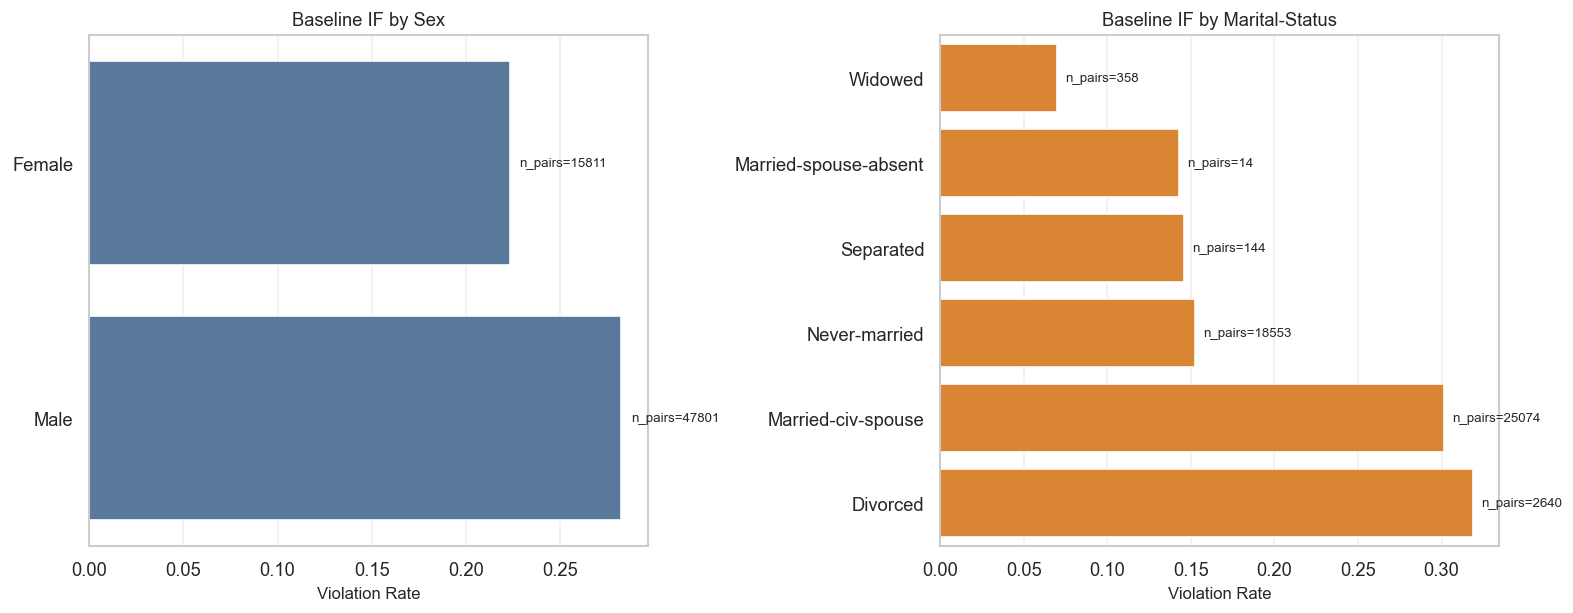

In [13]:
# Baseline subgroup IF bar charts (sex + marital-status)
sex_tbl_viz = within_group_if_table_from_labels(sensitive_test["sex"], "sex").copy()
marital_tbl_viz = within_group_if_table_from_labels(sensitive_test["marital-status"], "marital-status").copy()

sex_tbl_viz = sex_tbl_viz[sex_tbl_viz["violation_rate"].notna()].sort_values("violation_rate", ascending=True)
marital_tbl_viz = marital_tbl_viz[marital_tbl_viz["violation_rate"].notna()].sort_values("violation_rate", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.barplot(data=sex_tbl_viz, x="violation_rate", y="subgroup", ax=axes[0], color="#4C78A8")
axes[0].set_title("Baseline IF by Sex")
axes[0].set_xlabel("Violation Rate")
axes[0].set_ylabel("")
for i, row in enumerate(sex_tbl_viz.itertuples(index=False)):
    axes[0].text(row.violation_rate + 0.005, i, f"n_pairs={int(row.n_pairs)}", va="center", fontsize=8)

sns.barplot(data=marital_tbl_viz, x="violation_rate", y="subgroup", ax=axes[1], color="#F58518")
axes[1].set_title("Baseline IF by Marital-Status")
axes[1].set_xlabel("Violation Rate")
axes[1].set_ylabel("")
for i, row in enumerate(marital_tbl_viz.itertuples(index=False)):
    axes[1].text(row.violation_rate + 0.005, i, f"n_pairs={int(row.n_pairs)}", va="center", fontsize=8)

for ax in axes:
    ax.set_xlim(left=0)
    ax.grid(axis="x", alpha=0.3)

plt.show()


> **Figure 2: Baseline Intersection IF Heatmap**
> Heatmap of baseline within-group IF violation rates for the `marital-status x sex` intersection, annotated with `n_pairs` (low-support cells should be interpreted cautiously).


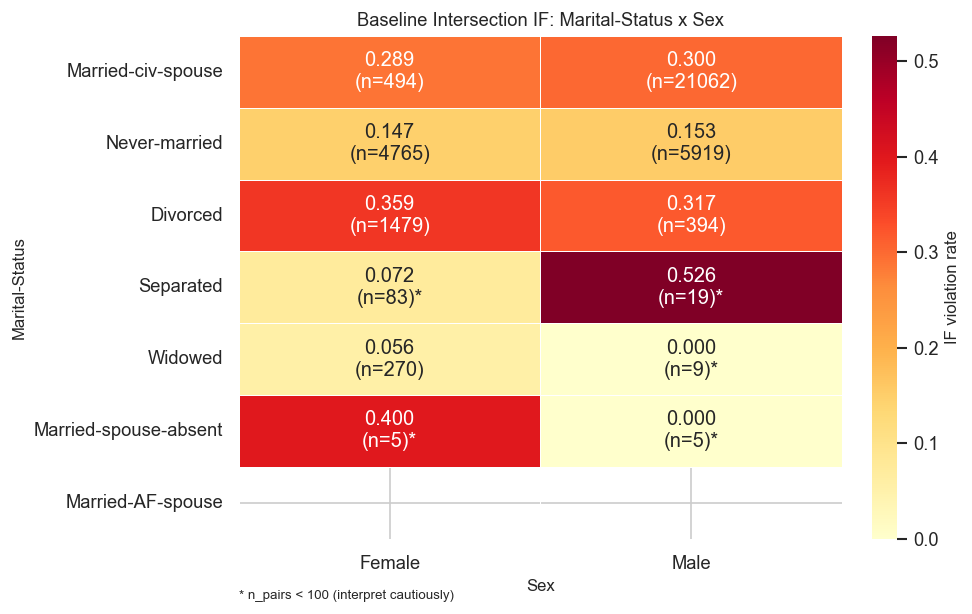

In [14]:
# Baseline intersection IF heatmap (marital-status x sex)
intersection_name_viz = globals().get("intersection_name", "marital-status x sex")
intersection_labels_viz = (
    sensitive_test["marital-status"].fillna("<missing>").astype(str)
    + " | "
    + sensitive_test["sex"].fillna("<missing>").astype(str)
)
intersection_tbl_viz = within_group_if_table_from_labels(intersection_labels_viz, intersection_name_viz).copy()
intersection_tbl_viz = intersection_tbl_viz[intersection_tbl_viz["violation_rate"].notna()].copy()

split_cols = intersection_tbl_viz["subgroup"].str.split(" | ", n=1, regex=False, expand=True)
intersection_tbl_viz["marital_status"] = split_cols[0]
intersection_tbl_viz["sex"] = split_cols[1]

marital_order = sensitive_test["marital-status"].astype(str).value_counts().index.tolist()
sex_order = [s for s in ["Female", "Male"] if s in intersection_tbl_viz["sex"].unique().tolist()]
for s in intersection_tbl_viz["sex"].unique().tolist():
    if s not in sex_order:
        sex_order.append(s)

heat_rate = intersection_tbl_viz.pivot(index="marital_status", columns="sex", values="violation_rate").reindex(index=marital_order, columns=sex_order)
heat_n = intersection_tbl_viz.pivot(index="marital_status", columns="sex", values="n_pairs").reindex(index=marital_order, columns=sex_order)

annot = heat_rate.copy().astype(object)
for r in heat_rate.index:
    for c in heat_rate.columns:
        vr = heat_rate.loc[r, c]
        npairs = heat_n.loc[r, c]
        if pd.isna(vr):
            annot.loc[r, c] = ""
        else:
            caution = "*" if (pd.notna(npairs) and npairs < viz13_min_pairs) else ""
            annot.loc[r, c] = f"{vr:.3f}\n(n={int(npairs)}){caution}"

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.heatmap(
    heat_rate,
    annot=annot,
    fmt="",
    cmap="YlOrRd",
    vmin=0,
    vmax=max(0.01, float(np.nanmax(heat_rate.values)) if np.isfinite(np.nanmax(heat_rate.values)) else 1.0),
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "IF violation rate"},
    ax=ax,
)
ax.set_title("Baseline Intersection IF: Marital-Status x Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Marital-Status")
ax.text(0.0, -0.12, f"* n_pairs < {viz13_min_pairs} (interpret cautiously)", transform=ax.transAxes, fontsize=8)
plt.show()


> **Figure 3: Data Skew Heatmaps (Full Dataset)**
> Side-by-side heatmaps for intersection counts (`n_samples`) and `>50K` positive rates, showing representation skew and label-rate skew across `marital-status x sex`.


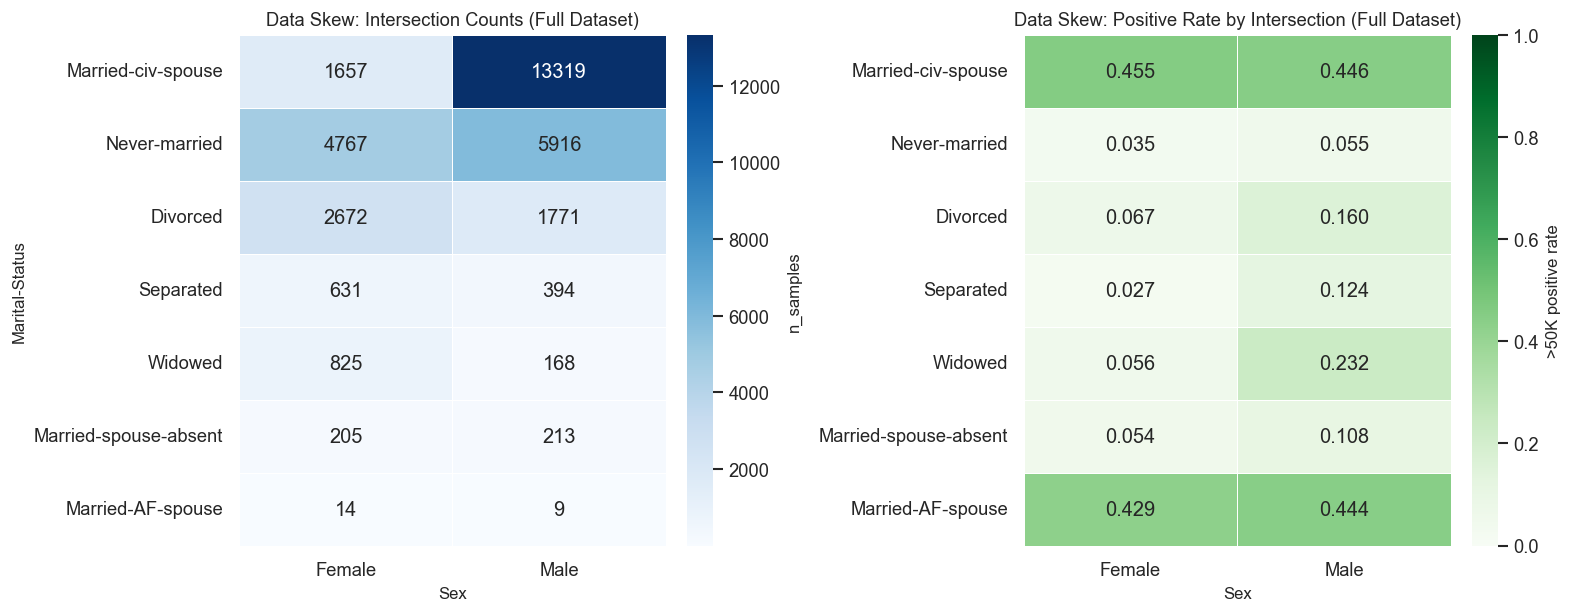

In [15]:
# Data skew heatmaps (full dataset): counts and positive rates by intersection
full_diag_viz = data[analysis_attrs + [target]].copy()
full_diag_viz["marital-status x sex"] = (
    full_diag_viz["marital-status"].fillna("<missing>").astype(str)
    + " | "
    + full_diag_viz["sex"].fillna("<missing>").astype(str)
)
full_diag_viz["__positive__"] = (full_diag_viz[target] == viz13_positive_label).astype(int)

counts_tbl = (
    full_diag_viz.groupby(["marital-status", "sex"]).size().rename("n_samples").reset_index()
)
rates_tbl = (
    full_diag_viz.groupby(["marital-status", "sex"])["__positive__"].mean().rename("positive_rate").reset_index()
)

marital_order_full = full_diag_viz["marital-status"].astype(str).value_counts().index.tolist()
sex_order_full = [s for s in ["Female", "Male"] if s in full_diag_viz["sex"].astype(str).unique().tolist()]
for s in full_diag_viz["sex"].astype(str).unique().tolist():
    if s not in sex_order_full:
        sex_order_full.append(s)

count_heat = counts_tbl.pivot(index="marital-status", columns="sex", values="n_samples").reindex(index=marital_order_full, columns=sex_order_full)
rate_heat = rates_tbl.pivot(index="marital-status", columns="sex", values="positive_rate").reindex(index=marital_order_full, columns=sex_order_full)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.heatmap(
    count_heat,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "n_samples"},
    ax=axes[0],
)
axes[0].set_title("Data Skew: Intersection Counts (Full Dataset)")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Marital-Status")

sns.heatmap(
    rate_heat,
    annot=True,
    fmt=".3f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": ">50K positive rate"},
    ax=axes[1],
)
axes[1].set_title("Data Skew: Positive Rate by Intersection (Full Dataset)")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("")

plt.show()


> **Figure 4: Data Intervention Effects (Sex-Balanced Undersampling, 3 Seeds)**
> Baseline vs seed-level runs for key fairness and performance metrics, including `sex` IF gap and `marital-status` IF spread.


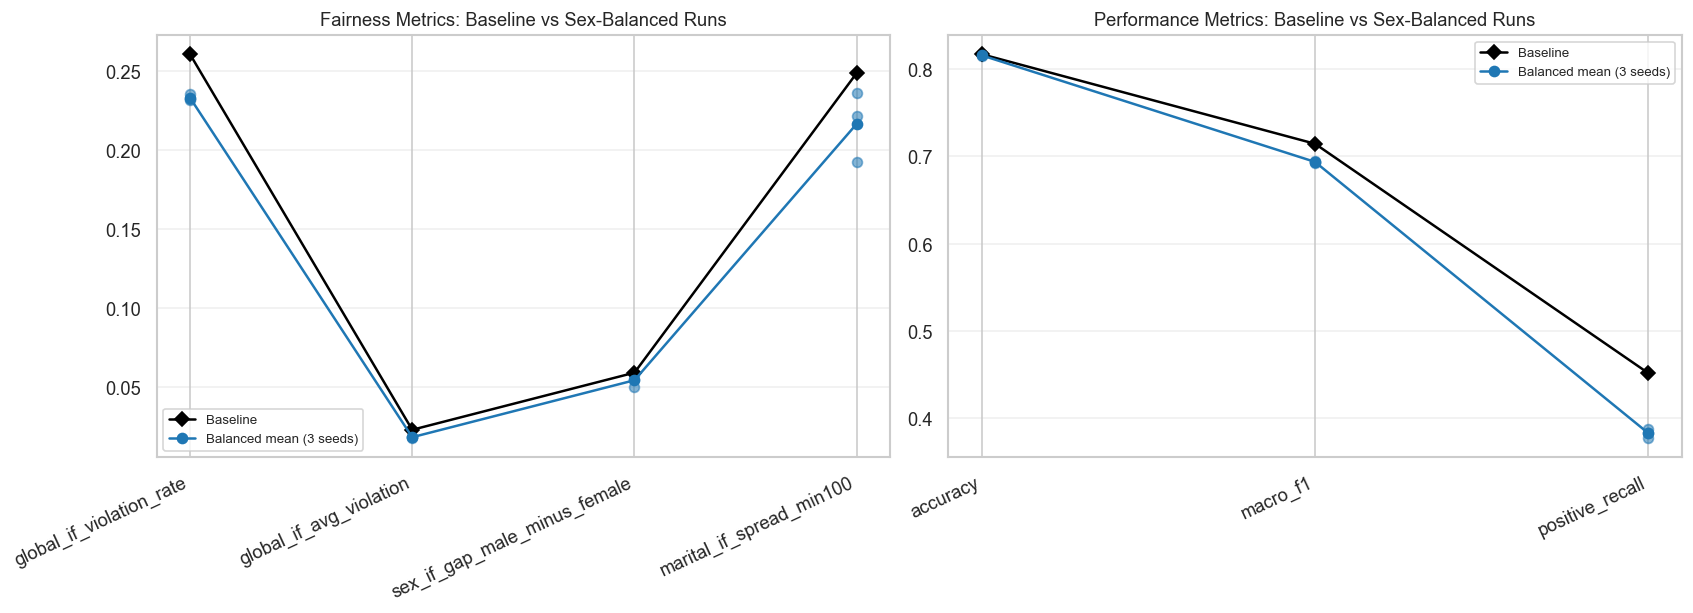

In [16]:
# Data intervention (sex-balanced undersampling) visual summary
if9_viz = if9_results.copy()
if9_viz["run_label"] = if9_viz.apply(
    lambda r: "baseline" if r["experiment"] == "baseline_current_train" else f"seed {int(r['seed'])}",
    axis=1,
)

fair_metrics = [
    "global_if_violation_rate",
    "global_if_avg_violation",
    "sex_if_gap_male_minus_female",
    "marital_if_spread_min100",
]
perf_metrics = ["accuracy", "macro_f1", "positive_recall"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, metrics, title in [
    (axes[0], fair_metrics, "Fairness Metrics: Baseline vs Sex-Balanced Runs"),
    (axes[1], perf_metrics, "Performance Metrics: Baseline vs Sex-Balanced Runs"),
]:
    x_positions = np.arange(len(metrics))
    baseline_row = if9_viz[if9_viz["experiment"] == "baseline_current_train"].iloc[0]
    seed_rows = if9_viz[if9_viz["experiment"] == "sex_balanced_undersample"].copy()

    baseline_vals = [baseline_row[m] for m in metrics]
    mean_vals = [seed_rows[m].mean() for m in metrics]

    ax.plot(x_positions, baseline_vals, marker="D", color="black", linewidth=1.5, label="Baseline")
    ax.plot(x_positions, mean_vals, marker="o", color="#1f77b4", linewidth=1.5, label="Balanced mean (3 seeds)")

    for _, sr in seed_rows.iterrows():
        vals = [sr[m] for m in metrics]
        ax.scatter(x_positions, vals, color="#1f77b4", alpha=0.55, s=35)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(metrics, rotation=25, ha="right")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="best", fontsize=8)

plt.show()


> **Figure 5: Proxy Signal Check (Sex and Marital-Status)**
> Grouped bars comparing majority baseline vs logistic probe for both protected attributes on accuracy and macro-F1.


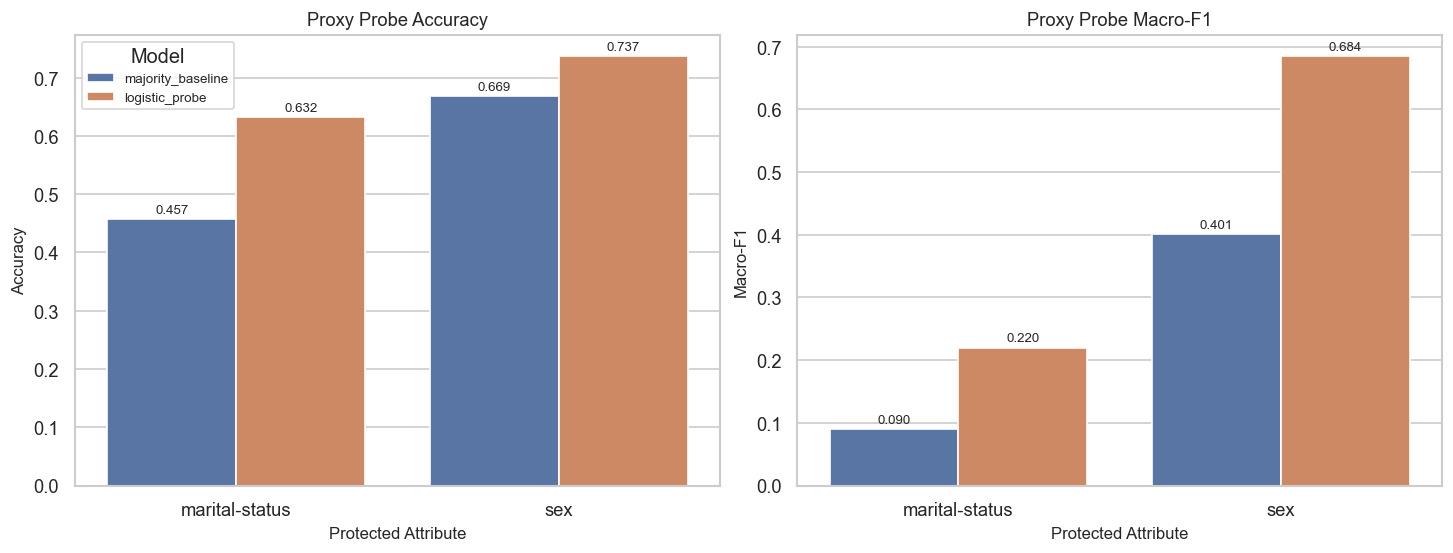

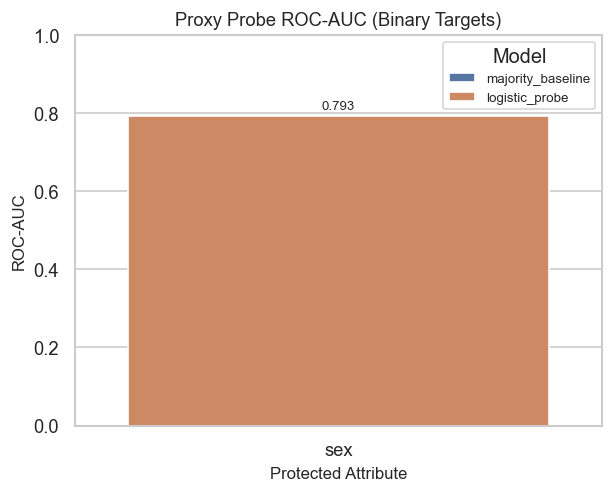

In [17]:
# Proxy signal check visual summary (sex + marital-status)
proxy_viz = if10_proxy_results_all.copy()
proxy_viz["model"] = pd.Categorical(proxy_viz["model"], categories=["majority_baseline", "logistic_probe"], ordered=True)
proxy_viz = proxy_viz.sort_values(["protected_attribute", "model"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

sns.barplot(data=proxy_viz, x="protected_attribute", y="accuracy", hue="model", ax=axes[0])
axes[0].set_title("Proxy Probe Accuracy")
axes[0].set_xlabel("Protected Attribute")
axes[0].set_ylabel("Accuracy")
axes[0].legend(title="Model", fontsize=8)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=8, padding=2)

sns.barplot(data=proxy_viz, x="protected_attribute", y="macro_f1", hue="model", ax=axes[1])
axes[1].set_title("Proxy Probe Macro-F1")
axes[1].set_xlabel("Protected Attribute")
axes[1].set_ylabel("Macro-F1")
axes[1].legend_.remove()
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.show()

# Optional: binary ROC-AUC bar (only available for the sex probe here)
proxy_auc = proxy_viz[proxy_viz["roc_auc"].notna()].copy()
if not proxy_auc.empty:
    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
    sns.barplot(data=proxy_auc, x="protected_attribute", y="roc_auc", hue="model", ax=ax)
    ax.set_title("Proxy Probe ROC-AUC (Binary Targets)")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Protected Attribute")
    ax.set_ylabel("ROC-AUC")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
    ax.legend(title="Model", fontsize=8)
    plt.show()


> **Figure 6: Method Sensitivity (Vary `k`)**
> Line plots show how fairness and performance change when only the KNN neighborhood size `k` changes, plus a fairness-performance tradeoff scatter.


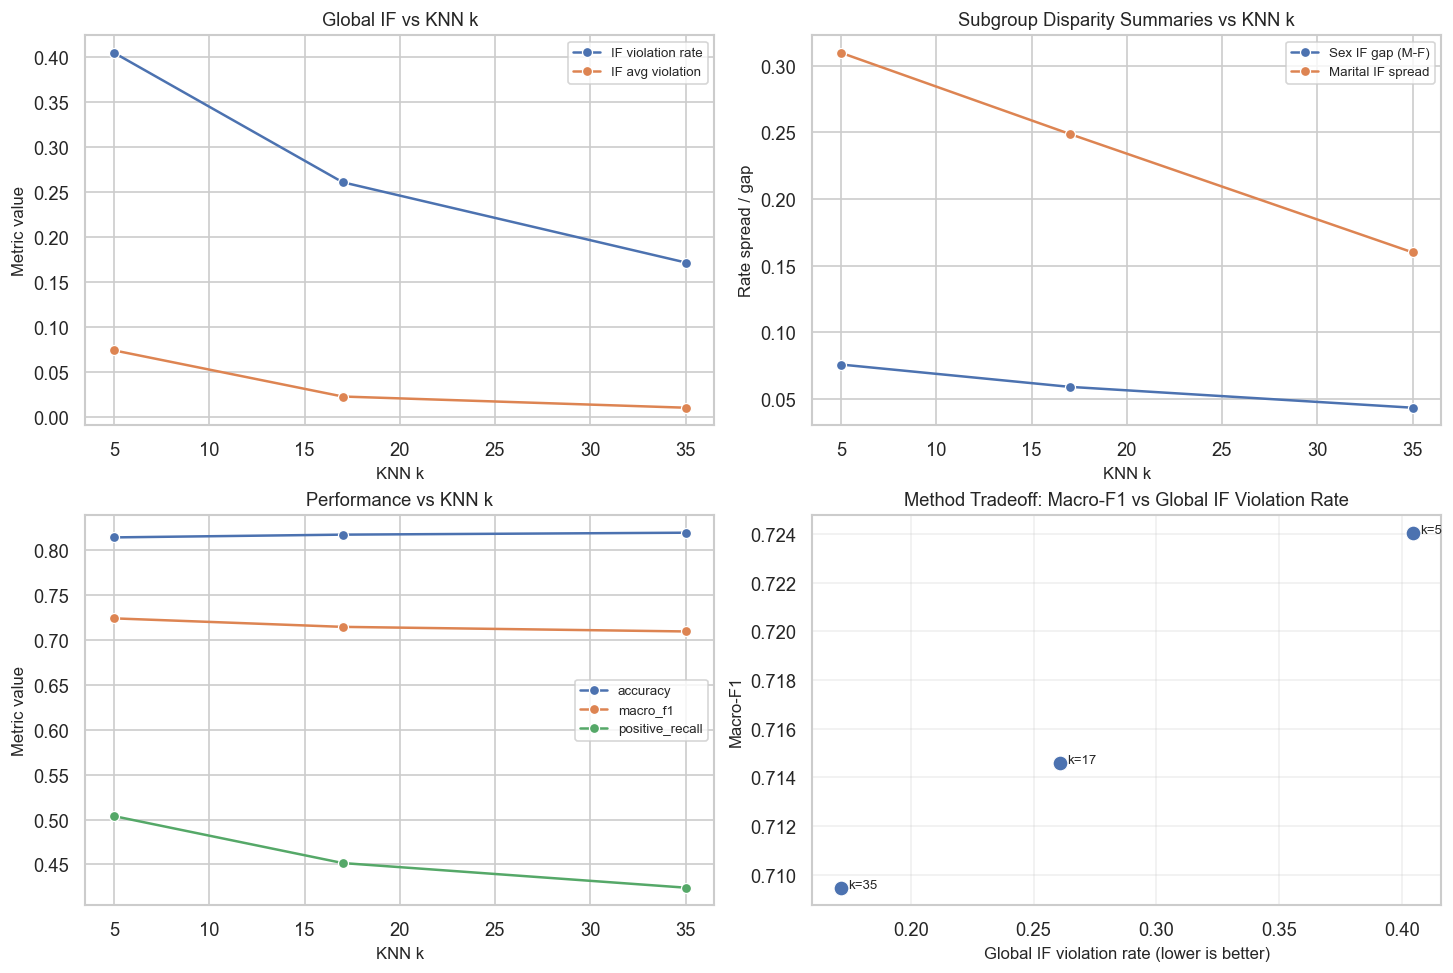

In [18]:
# Method sensitivity visual summary (vary k only)
if11_viz = if11_results.copy().sort_values("k").reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Global IF metrics vs k
sns.lineplot(data=if11_viz, x="k", y="global_if_violation_rate", marker="o", ax=axes[0, 0], label="IF violation rate")
sns.lineplot(data=if11_viz, x="k", y="global_if_avg_violation", marker="o", ax=axes[0, 0], label="IF avg violation")
axes[0, 0].set_title("Global IF vs KNN k")
axes[0, 0].set_xlabel("KNN k")
axes[0, 0].set_ylabel("Metric value")
axes[0, 0].legend(fontsize=8)

# Group disparity summaries vs k
sns.lineplot(data=if11_viz, x="k", y="sex_if_gap_male_minus_female", marker="o", ax=axes[0, 1], label="Sex IF gap (M-F)")
sns.lineplot(data=if11_viz, x="k", y="marital_if_spread_min100", marker="o", ax=axes[0, 1], label="Marital IF spread")
axes[0, 1].set_title("Subgroup Disparity Summaries vs KNN k")
axes[0, 1].set_xlabel("KNN k")
axes[0, 1].set_ylabel("Rate spread / gap")
axes[0, 1].legend(fontsize=8)

# Performance metrics vs k
perf_long = if11_viz.melt(id_vars=["k"], value_vars=["accuracy", "macro_f1", "positive_recall"], var_name="metric", value_name="value")
sns.lineplot(data=perf_long, x="k", y="value", hue="metric", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Performance vs KNN k")
axes[1, 0].set_xlabel("KNN k")
axes[1, 0].set_ylabel("Metric value")
axes[1, 0].legend(fontsize=8)

# Fairness-performance tradeoff scatter
sns.scatterplot(data=if11_viz, x="global_if_violation_rate", y="macro_f1", s=80, ax=axes[1, 1])
for row in if11_viz.itertuples(index=False):
    axes[1, 1].text(row.global_if_violation_rate + 0.003, row.macro_f1, f"k={int(row.k)}", fontsize=8)
axes[1, 1].set_title("Method Tradeoff: Macro-F1 vs Global IF Violation Rate")
axes[1, 1].set_xlabel("Global IF violation rate (lower is better)")
axes[1, 1].set_ylabel("Macro-F1")
axes[1, 1].grid(alpha=0.3)

plt.show()
